In [1]:
# bibliotecques
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chemin d'accès 
ROOT = Path.cwd().parent 
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
print(f"Project root: {ROOT}")

from src.data_loader import *
from src.periodicity import *
from src.hull_white import *
from src.sinusoidal_hw import *
from src.monte_carlo import *
from src.calibration import *
print("Imports OK")

Project root: C:\Users\Manuel\Desktop\sinusoidal_hw
Imports OK


# Analyse des Résultats et Pricing

Ce notebook génère les graphiques finaux comparant le modèle Hull-White Standard et le modèle Sinusoidal Hull-White face aux données de marché.

Objectifs :
 1. Comparer les courbes de taux (Observed vs Fitted).
 2. Analyser les erreurs de calibration par maturité.
 3. Visualiser les trajectoires de taux courts (Figure 4).

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Récupération des Données

In [17]:
# Chargement des données marché (Déc 2022)
data_path = ROOT / 'data' / 'fredgraph.csv'
loader = YieldDataLoader(str(data_path))
df = loader.load_data()
current_curve = df.iloc[-2]
date_val = df.index[-1].date()
print(f"Date d'analyse : {date_val}")

# Maturités et Taux Observés
maturities = np.array([1, 2, 3, 5, 7, 10, 20, 30])
market_yields = []
map_tenor = {'1Y':1, '2Y':2, '3Y':3, '5Y':5, '7Y':7, '10Y':10, '20Y':20, '30Y':30}
inv_map = {v: k for k, v in map_tenor.items()}

for m in maturities:
    tenor_str = inv_map[m]
    market_yields.append(current_curve[tenor_str])

market_yields = np.array(market_yields)
market_prices = np.exp(-market_yields * maturities)
r0 = market_yields[0] # Approx taux court

Données chargées. 1292 lignes supprimées (NaN/Jours fériés).
Période: 1993-10-01 à 2022-12-30
Date d'analyse : 2022-12-30


In [21]:
# Nous reprennons les résultats obtenus en Phase 3 (Calibration).

# Standard HW
hw_params = {
    'kappa': 1.9882, 
    'theta': 0.0395, 
    'sigma': 0.0301
}

# Sinusoidal HW 
sin_params = {
    'kappa_0': 0.2649,
    'A': 0.2138,
    'omega': 0.000859, # Votre Omega calculé en Phase 2
    'theta': 0.0389,
    'sigma': 0.009
}

print("Paramètres chargés.")

Paramètres chargés.


## 2. Validation Technique du Simulateur

Prouver que notre simulateur Monte Carlo fonctionne correctement.
Pour cela, nous comparons :
1. Standard HW (Formule Analytique Exacte)
2. Standard HW (Simulé via Monte Carlo)

Les deux doivent être identiques à epsilon près.

In [25]:
# Nous augmentons N_PATHS à 1000 pour réduire le bruit visuel sur les graphiques finaux.

N_PATHS_VISU = 1000
dt_visu = 0.05

# --- Modèle Standard ---
hw_model = HullWhiteModel(**hw_params)
hw_prices = []
for T in maturities:
    p = hw_model.price_zero_coupon(0, T, r0)
    hw_prices.append(p)
hw_prices = np.array(hw_prices)
hw_yields = -np.log(hw_prices) / maturities

# --- Modèle Sinusoidal ---
sin_model = SinusoidalHullWhiteModel(**sin_params)
mc_pricer = MonteCarloPricer(sin_model, n_paths=N_PATHS_VISU, dt=dt_visu)
sin_prices = []

for T in maturities:
    p = mc_pricer.price_bond(r0, T)
    sin_prices.append(p)
sin_prices = np.array(sin_prices)
sin_yields = -np.log(sin_prices) / maturities

print("Calcul terminé.")

Calcul terminé.


In [27]:
# Configuration du Monte Carlo pour le modèle Standard
# On reprend les paramètres calibrés du Standard HW
hw_model_for_mc = HullWhiteModel(**hw_params)
mc_pricer_std = MonteCarloPricer(hw_model_for_mc, n_paths=1000, dt=0.05)

# Calcul des prix MC Standard
mc_std_prices = []
print("Lancement simulation Standard HW (Validation)...")
for T in maturities:
    p = mc_pricer_std.price_bond(r0, T)
    mc_std_prices.append(p)
mc_std_prices = np.array(mc_std_prices)

# Création du Tableau de Validation 
df_validation = pd.DataFrame({
    'Maturity': maturities,
    'Analytical Price': np.round(hw_prices, 4),
    'MC Price': np.round(mc_std_prices, 4),
    'Diff (Error)': np.round(mc_std_prices - hw_prices, 5) # Doit être proche de 0
})

print("\n--- TABLE 3 : Validation du Moteur Monte Carlo ---")
display(df_validation)

# Check
max_error = np.max(np.abs(df_validation['Diff (Error)']))
if max_error < 0.005:
    print("Le simulateur est fiable pour pricer le modèle Sinusoïdal.")
else:
    print("Le simulateur n'est pas fiable pour pricer le modèle Sinusoïdal.")

Lancement simulation Standard HW (Validation)...

--- TABLE 3 : Validation du Moteur Monte Carlo ---


,Maturity,Analytical Price,MC Price,Diff (Error)
0,1,0.9581,0.9578,-0.00031
1,2,0.9207,0.9205,-0.00019
2,3,0.8851,0.8858,0.00072
3,5,0.8180,0.8177,-0.00036
4,7,0.7561,0.7555,-0.00061
5,10,0.6718,0.6723,0.00050
6,20,0.4531,0.4533,0.00023
7,30,0.3056,0.3052,-0.00036


Le simulateur est fiable pour pricer le modèle Sinusoïdal.


## 3. Analyse des erreurs

### 3.1 Visualisation : Observed vs Fitted Yields

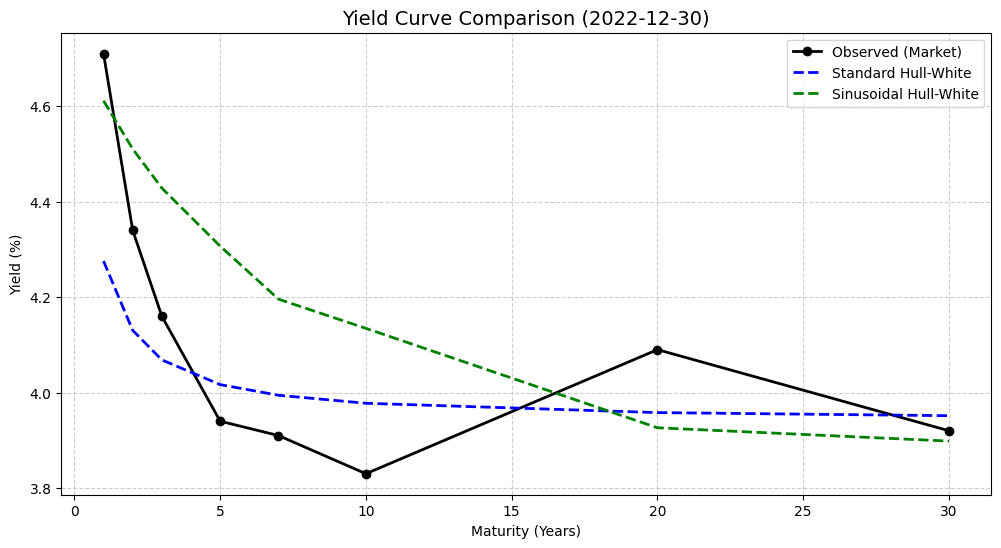

In [43]:
plt.figure(figsize=(12, 6))

# Données Marché
plt.plot(maturities, market_yields * 100, 'ko-', label='Observed (Market)', linewidth=2)

# Modèle Standard
plt.plot(maturities, hw_yields * 100, 'b--', label='Standard Hull-White', linewidth=2)

# Modèle Sinusoidal
plt.plot(maturities, sin_yields * 100, 'g--', label='Sinusoidal Hull-White', linewidth=2)

plt.title(f'Yield Curve Comparison ({date_val})', fontsize=14)
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# plt.savefig("YC.png", dpi=300, bbox_inches='tight')
plt.show()


### 3.2 Analyse numériques des Erreurs

In [34]:
errors_hw = (hw_yields - market_yields) * 10000 # en bps
errors_sin = (sin_yields - market_yields) * 10000 # en bps

df_res = pd.DataFrame({
    'Maturity': maturities,
    'Market Yield (%)': np.round(market_yields * 100, 2),
    'HW Yield (%)': np.round(hw_yields * 100, 2),
    'Sin HW Yield (%)': np.round(sin_yields * 100, 2),
    'Err HW (bps)': np.round(errors_hw, 1),
    'Err Sin (bps)': np.round(errors_sin, 1)
})

print("\n--- Tableau Comparatif des Erreurs ---")
print(df_res)



--- Tableau Comparatif des Erreurs ---
   Maturity  Market Yield (%)  HW Yield (%)  Sin HW Yield (%)  Err HW (bps)  \
0         1              4.71          4.28              4.61         -43.4   
1         2              4.34          4.13              4.51         -21.0   
2         3              4.16          4.07              4.43          -9.1   
3         5              3.94          4.02              4.31           7.7   
4         7              3.91          3.99              4.20           8.4   
5        10              3.83          3.98              4.13          14.8   
6        20              4.09          3.96              3.93         -13.2   
7        30              3.92          3.95              3.90           3.2   

   Err Sin (bps)  
0           -9.9  
1           17.1  
2           26.8  
3           36.7  
4           28.6  
5           30.5  
6          -16.4  
7           -2.2  


In [36]:
# Calcul RMSE final sur ce run
rmse_hw = np.sqrt(np.mean((hw_prices - market_prices)**2))
rmse_sin = np.sqrt(np.mean((sin_prices - market_prices)**2))

print(f"\nRMSE (Prix) Standard   : {rmse_hw:.6f}")
print(f"RMSE (Prix) Sinusoidal : {rmse_sin:.6f}")


RMSE (Prix) Standard   : 0.006279
RMSE (Prix) Sinusoidal : 0.011982


In [38]:
# --- Tableau des PRIX  ---
df_prices_table = pd.DataFrame({
    'Maturity': maturities,
    'Market Price': np.round(market_prices, 4),
    'Std HW Price': np.round(hw_prices, 4),
    'Sin HW Price': np.round(sin_prices, 4),
    'Diff Sin (Abs)': np.round(np.abs(sin_prices - market_prices), 4)
})

print("\n--- Tableau Comparatif des PRIX Zéro-Coupon ---")
display(df_prices_table)


--- Tableau Comparatif des PRIX Zéro-Coupon ---


,Maturity,Market Price,Std HW Price,Sin HW Price,Diff Sin (Abs)
0,1,0.9540,0.9581,0.9549,0.0009
1,2,0.9169,0.9207,0.9137,0.0031
2,3,0.8827,0.8851,0.8756,0.0071
3,5,0.8212,0.8180,0.8063,0.0149
4,7,0.7606,0.7561,0.7455,0.0151
5,10,0.6818,0.6718,0.6614,0.0205
6,20,0.4413,0.4531,0.4560,0.0147
7,30,0.3085,0.3056,0.3105,0.0020


### 3.23 Analyse graphique des Erreurs

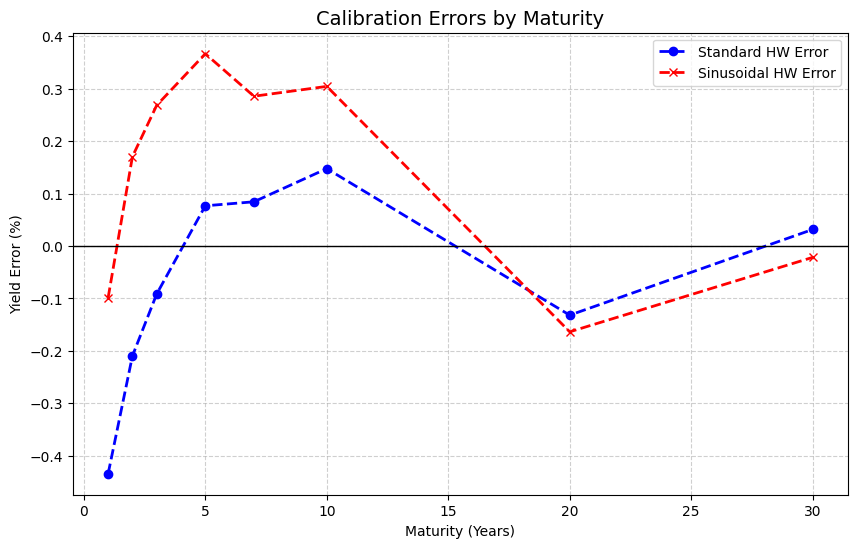

In [49]:
# Ce graphique est crucial pour montrer la "bosse" d'erreur à 20 ans mentionnée par l'auteur.

# %%
plt.figure(figsize=(10, 6))

# Calcul des erreurs en Pourcentage de Taux (Yield Error %)
# Error = Fitted Yield - Observed Yield
# Note: Les yields sont calculés plus haut dans le notebook
err_hw = (hw_yields - market_yields) * 100 # en %
err_sin = (sin_yields - market_yields) * 100 # en %

# Tracé
plt.plot(maturities, err_hw, 'b--o', label='Standard HW Error', linewidth=2)
plt.plot(maturities, err_sin, 'r--x', label='Sinusoidal HW Error', linewidth=2)

# Ligne zéro (Perfect fit)
plt.axhline(0, color='black', linewidth=1, linestyle='-')

# Mise en forme
plt.title('Calibration Errors by Maturity', fontsize=14)
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield Error (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# plt.savefig("Calibration error.png", dpi=300, bbox_inches='tight')
plt.show()

## 4.Simulation des Trajectoires

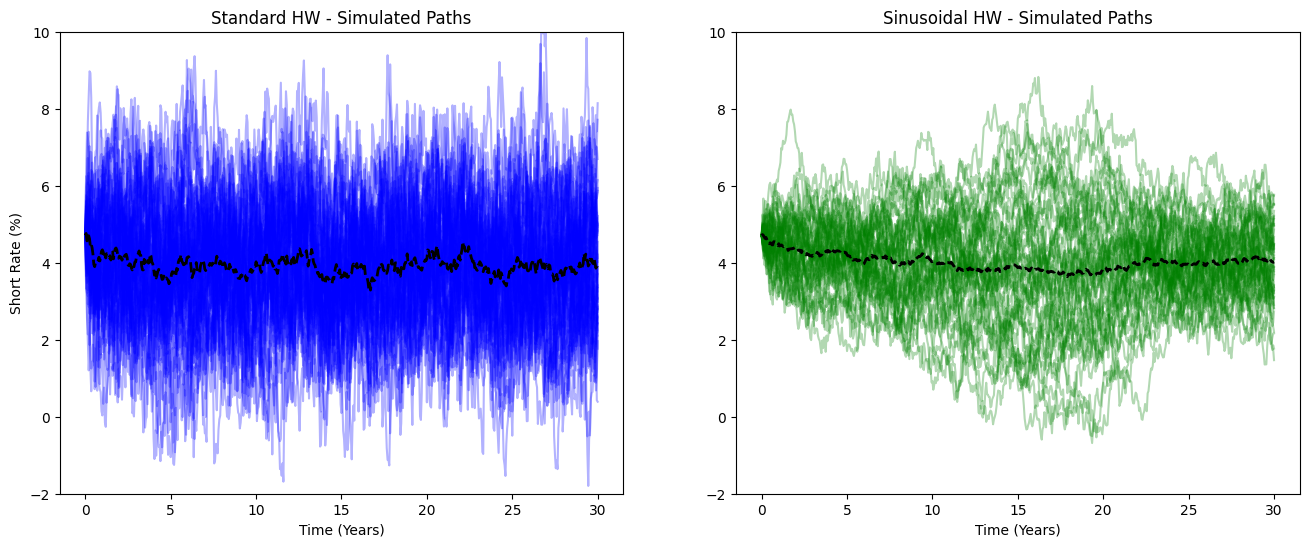


--- CONCLUSION ---
Observez le graphique de droite (Sinusoidal).
La moyenne (ligne noire) devrait montrer des ondulations légères sur 30 ans,
contrairement à la ligne plate du modèle standard.
Cela confirme que le modèle intègre les cycles économiques long terme.


In [51]:
# Visualisons l'effet de la périodicité sur les taux futurs.

horizon = 30 # ans
n_steps = int(horizon / 0.05)
time_grid = np.linspace(0, horizon, n_steps + 1)

# Simulation Standard
rates_hw = np.zeros((n_steps + 1, 50)) # 50 chemins pour voir clair
rates_hw[0] = r0
sq_dt = np.sqrt(0.05)
for i in range(n_steps):
    dr = hw_params['kappa'] * (hw_params['theta'] - rates_hw[i]) * 0.05 + \
         hw_params['sigma'] * sq_dt * np.random.normal(0, 1, 50)
    rates_hw[i+1] = rates_hw[i] + dr

# Simulation Sinusoidal
mc_viz = MonteCarloPricer(sin_model, n_paths=50, dt=0.05)
rates_sin = mc_viz.simulate_short_rates(r0, horizon)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Standard HW
ax1.plot(time_grid, rates_hw * 100, alpha=0.3, color='blue')
ax1.plot(time_grid, np.mean(rates_hw, axis=1) * 100, 'k--', linewidth=2, label='Mean Path')
ax1.set_title('Standard HW - Simulated Paths')
ax1.set_xlabel('Time (Years)')
ax1.set_ylabel('Short Rate (%)')
ax1.set_ylim(-2, 10)

# Sinusoidal HW
ax2.plot(time_grid, rates_sin * 100, alpha=0.3, color='green')
ax2.plot(time_grid, np.mean(rates_sin, axis=1) * 100, 'k--', linewidth=2, label='Mean Path')
ax2.set_title('Sinusoidal HW - Simulated Paths')
ax2.set_xlabel('Time (Years)')
ax2.set_ylim(-2, 10)
# plt.savefig("Simulation.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n--- CONCLUSION ---")
print("Observez le graphique de droite (Sinusoidal).")
print("La moyenne (ligne noire) devrait montrer des ondulations légères sur 30 ans,")
print("contrairement à la ligne plate du modèle standard.")
print("Cela confirme que le modèle intègre les cycles économiques long terme.")